# Họ và Tên: Huynh Ngoc Gia Bao
# MSSV: 2174802010066

### Câu 1 (2 điểm): Cho một ảnh bất kỳ (tên ảnh do sinh viên tự đặt, ví dụ: `my_image.jpg`) và thực hiện các yêu cầu sau:

* Viết chương trình sử dụng median filter để làm mịn ảnh. (0.5 điểm)  
* Viết chương trình sử dụng Sobel filter để xác định biên của hình ảnh. (0.5 điểm)  
* Đổi màu ảnh bằng cách hoán đổi thứ tự các kênh màu (ví dụ: BGR → GRB hoặc GBR...) và lưu thành tên dạng `[ten_anh]_swapped.jpg`. (0.5 điểm)  
* Chuyển ảnh sang không gian màu LAB và tách riêng 3 kênh L, A, B, lưu thành ảnh grayscale tương ứng (`[ten_anh]_L.jpg`, `[ten_anh]_A.jpg`, `[ten_anh]_B.jpg`). (0.5 điểm)


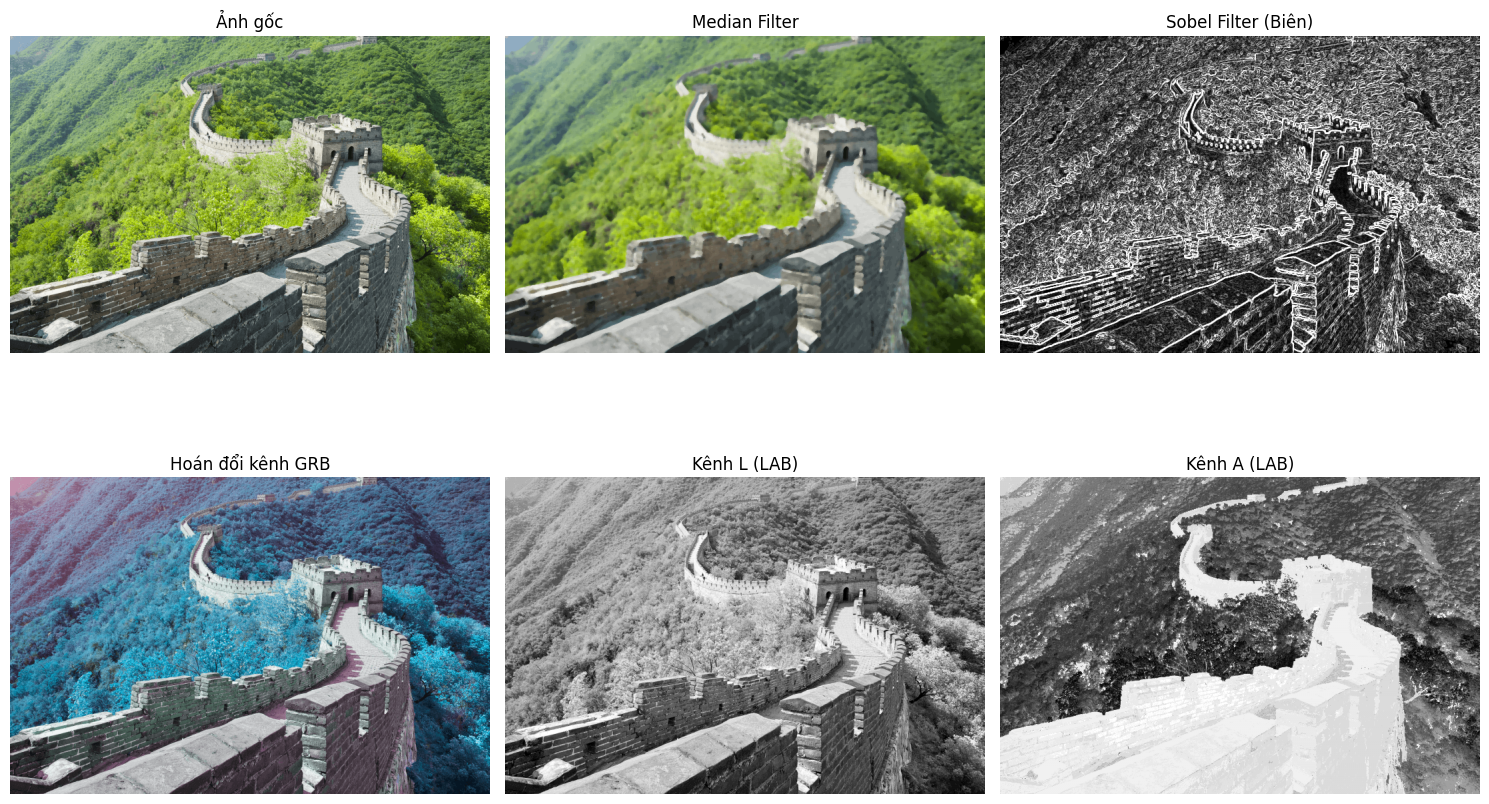

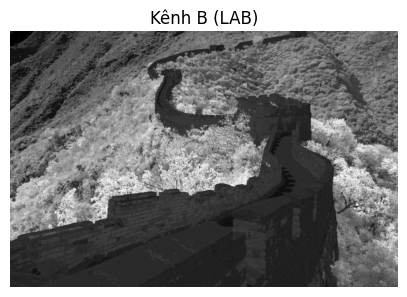

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh gốc
img = cv2.imread("GiaBao.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Làm mịn ảnh bằng median filter
median_blur = cv2.medianBlur(img, 5)

# 2. Dò biên ảnh bằng Sobel filter
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = np.uint8(np.clip(sobel, 0, 255))

# 3. Hoán đổi thứ tự kênh màu: BGR → GRB
swapped = img[:, :, [1, 2, 0]]
cv2.imwrite("GiaBao_swapped.jpg", swapped)

# 4. Chuyển sang LAB và tách kênh
lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab)
cv2.imwrite("GiaBao_L.jpg", L)
cv2.imwrite("GiaBao_A.jpg", A)
cv2.imwrite("GiaBao_B.jpg", B)

# Hiển thị tất cả ảnh
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title("Ảnh gốc")
axs[0, 0].axis("off")

axs[0, 1].imshow(cv2.cvtColor(median_blur, cv2.COLOR_BGR2RGB))
axs[0, 1].set_title("Median Filter")
axs[0, 1].axis("off")

axs[0, 2].imshow(sobel, cmap="gray")
axs[0, 2].set_title("Sobel Filter (Biên)")
axs[0, 2].axis("off")

axs[1, 0].imshow(cv2.cvtColor(swapped, cv2.COLOR_BGR2RGB))
axs[1, 0].set_title("Hoán đổi kênh GRB")
axs[1, 0].axis("off")

axs[1, 1].imshow(L, cmap="gray")
axs[1, 1].set_title("Kênh L (LAB)")
axs[1, 1].axis("off")

axs[1, 2].imshow(A, cmap="gray")
axs[1, 2].set_title("Kênh A (LAB)")
axs[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Thêm kênh B vào hình riêng nếu cần
plt.figure(figsize=(5,5))
plt.title("Kênh B (LAB)")
plt.imshow(B, cmap="gray")
plt.axis("off")
plt.show()


### Câu 2 (4 điểm) Viết một chương trình Python sử dụng OpenCV để tạo menu tương tác cho phép người dùng chọn các kỹ thuật lọc và xử lý ảnh nâng cao từ một danh sách, áp dụng đồng thời cho nhiều ảnh.

### Yêu cầu:

1. Menu gồm:  
* Gaussian Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Median Blur (kernel size ngẫu nhiên lẻ từ 3 đến 11) (0.5 điểm)  
* Bilateral Filter (tham số ngẫu nhiên) (0.5 điểm)  
* Canny Edge Detection (thresholds ngẫu nhiên 50–150) (0.5 điểm)  
* Erosion (kernel 2x2 đến 5x5 ngẫu nhiên) (0.5 điểm)  
* Dilation (tương tự Erosion) (0.5 điểm)

2. Chương trình xử lý đồng thời 3 ảnh bất kỳ do sinh viên tự chọn (có thể chọn bằng đường dẫn file hoặc nhập tên ảnh tùy ý). (0.5 điểm)

3. Phím tương ứng để kích hoạt các phương pháp xử lý:  
* B: Gaussian Blur  
* M: Median Blur  
* F: Bilateral Filter  
* E: Canny Edge  
* R: Erosion  
* D: Dilation (0.5 điểm)

4. Lưu file kết quả với định dạng: `result_[phương pháp]_[tên ảnh gốc].jpg`  
   Ví dụ: `result_blur_dog.jpg`, `result_canny_image2.jpg` (0.5 điểm)


Nhấn một phím trong số sau để xử lý ảnh:
B - Gaussian Blur
M - Median Blur
F - Bilateral Filter
E - Canny Edge Detection
R - Erosion
D - Dilation


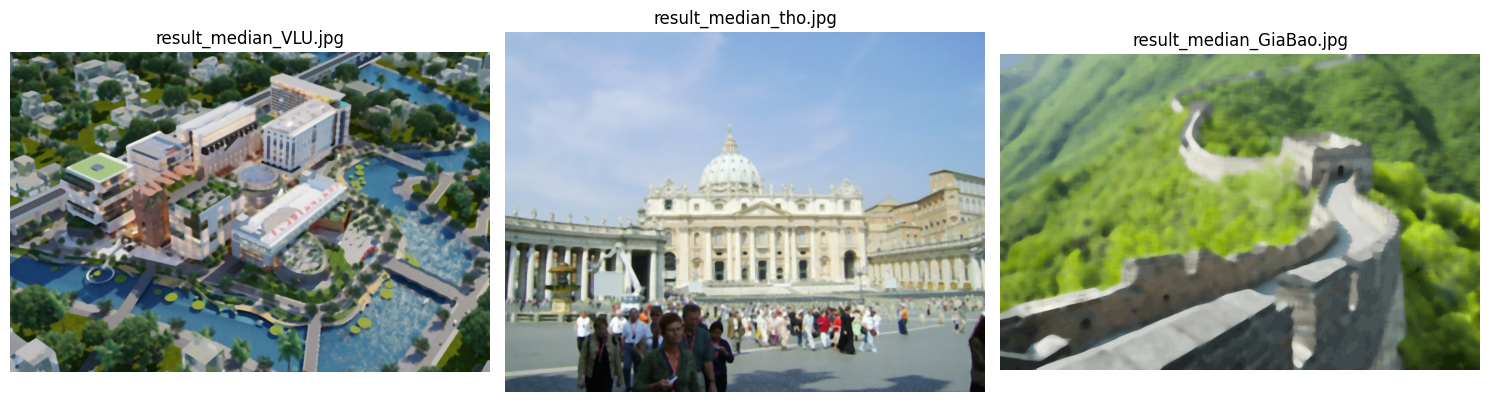

In [21]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import os

# Danh sách ảnh - Đã sửa đường dẫn: car.jpg → tho.jpg
image_paths = [
    "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/VLU.jpg",
    "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/tho.jpg",     # <- sửa ở đây
    "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/GiaBao.jpg"
]

# Đọc ảnh
images = []
for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"[❌] Không tìm thấy ảnh: {path}")
    else:
        images.append((img, os.path.basename(path)))

# Hàm xử lý ảnh
def process_images(key, images):
    results = []
    method = ""

    for img, name in images:
        if key == 'B':
            k = random.choice([3,5,7,9,11])
            output = cv2.GaussianBlur(img, (k,k), 0)
            method = "gaussian"
        elif key == 'M':
            k = random.choice([3,5,7,9,11])
            output = cv2.medianBlur(img, k)
            method = "median"
        elif key == 'F':
            d = random.randint(5, 15)
            output = cv2.bilateralFilter(img, d, 75, 75)
            method = "bilateral"
        elif key == 'E':
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            t1 = random.randint(50, 100)
            t2 = random.randint(100, 150)
            edge = cv2.Canny(gray, t1, t2)
            output = cv2.cvtColor(edge, cv2.COLOR_GRAY2BGR)
            method = "canny"
        elif key == 'R':
            k = random.randint(2, 5)
            kernel = np.ones((k,k), np.uint8)
            output = cv2.erode(img, kernel, iterations=1)
            method = "erosion"
        elif key == 'D':
            k = random.randint(2, 5)
            kernel = np.ones((k,k), np.uint8)
            output = cv2.dilate(img, kernel, iterations=1)
            method = "dilation"
        else:
            print("[!] Phím không hợp lệ.")
            return []

        out_name = f"result_{method}_{name}"
        cv2.imwrite(out_name, output)
        results.append((output, out_name))
    
    return results

# Hướng dẫn người dùng
print("Nhấn một phím trong số sau để xử lý ảnh:")
print("B - Gaussian Blur")
print("M - Median Blur")
print("F - Bilateral Filter")
print("E - Canny Edge Detection")
print("R - Erosion")
print("D - Dilation")

# Nhập phím xử lý
key = input("Nhập phím xử lý (B/M/F/E/R/D): ").upper()
results = process_images(key, images)

# Hiển thị kết quả
plt.figure(figsize=(15, 5))
for i, (img, name) in enumerate(results):
    plt.subplot(1, 3, i+1)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Câu 3 (4 điểm) Viết một chương trình Python để xử lý 3 ảnh bất kỳ do sinh viên tự chọn.

* Tăng kích thước ảnh đầu tiên thêm 35 pixel ở mỗi cạnh. (0.5 điểm)  
* Xoay ảnh thứ hai 135 độ và lật ngang. (0.5 điểm)  
* Tăng kích thước ảnh thứ ba lên 5 lần và làm mịn bằng Gaussian blur kernel 9x9. (1.5 điểm)  
* Thay đổi độ sáng và độ tương phản ảnh thứ ba bằng công thức:

$$
I_{out}(x, y) = \alpha \cdot I_{in}(x, y) + \beta
$$

Trong đó:  

$$
\alpha \in [0.5, 2.0], \quad \beta \in [-50, 50]
$$

Giá trị đầu ra cần được giới hạn trong khoảng [0, 255] bằng công thức:

$$
I_{out}(x, y) = \text{clip}(I_{out}(x, y), 0, 255)
$$


[✔] Đã đọc ảnh: VLU
[✔] Đã đọc ảnh: tho
[✔] Đã đọc ảnh: GiaBao
✅ Đã lưu ảnh: result_padded_VLU.jpg
✅ Đã lưu ảnh: result_rotated_flipped_tho.jpg
✅ Đã lưu ảnh: result_scaled_blur_GiaBao.jpg
✅ Đã lưu ảnh: result_adjusted_GiaBao.jpg (alpha=1.5, beta=30)


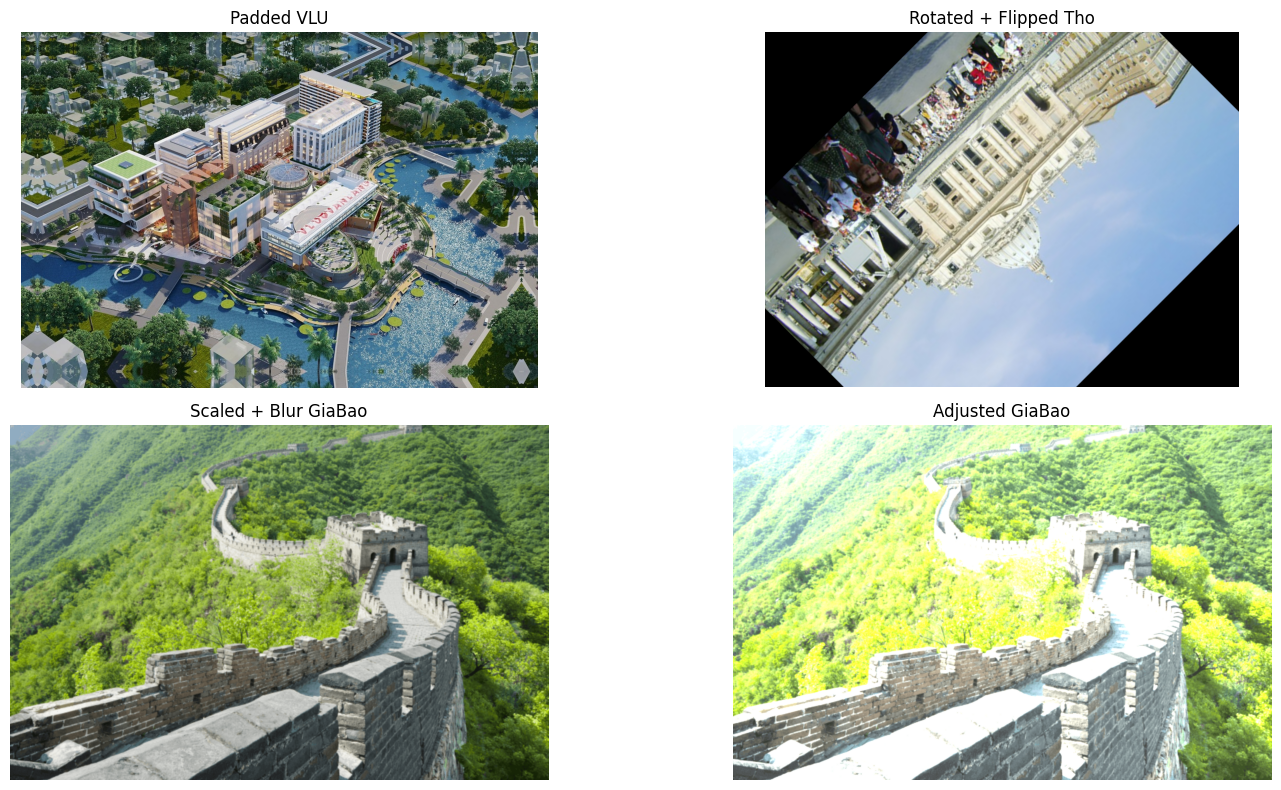

In [20]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Đường dẫn ảnh đã cập nhật
paths = {
    "VLU": "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/VLU.jpg",
    "tho": "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/tho.jpg",  # ảnh thứ hai
    "GiaBao": "D:/nhapmonxulyanhso/nhapmonxulyanhso/THI/GiaBao.jpg"
}

# Đọc ảnh với kiểm tra
imgs = {}
for name, path in paths.items():
    if not os.path.exists(path):
        print(f"[❌] Không tìm thấy ảnh: {path}")
    else:
        img = cv2.imread(path)
        if img is None:
            print(f"[❌] Ảnh bị lỗi hoặc định dạng không hợp lệ: {path}")
        else:
            imgs[name] = img
            print(f"[✔] Đã đọc ảnh: {name}")

# Nếu thiếu ảnh thì dừng
if len(imgs) < 3:
    raise FileNotFoundError("❌ Thiếu ảnh đầu vào! Kiểm tra lại đường dẫn và tên file.")

# ==== 1. Padding ảnh đầu tiên (VLU) ====
img1 = imgs["VLU"]
padded = cv2.copyMakeBorder(img1, 35, 35, 35, 35, cv2.BORDER_REFLECT)
cv2.imwrite("result_padded_VLU.jpg", padded)
print("✅ Đã lưu ảnh: result_padded_VLU.jpg")

# ==== 2. Xoay ảnh thứ hai (tho.jpg) 135 độ và lật ngang ====
img2 = imgs["tho"]
(h2, w2) = img2.shape[:2]
center = (w2 // 2, h2 // 2)
M = cv2.getRotationMatrix2D(center, 135, 1.0)
rotated = cv2.warpAffine(img2, M, (w2, h2))
flipped = cv2.flip(rotated, 1)
cv2.imwrite("result_rotated_flipped_tho.jpg", flipped)
print("✅ Đã lưu ảnh: result_rotated_flipped_tho.jpg")

# ==== 3. Phóng to ảnh thứ ba (GiaBao) và làm mịn ====
img3 = imgs["GiaBao"]
scaled = cv2.resize(img3, None, fx=5.0, fy=5.0, interpolation=cv2.INTER_LINEAR)
blurred = cv2.GaussianBlur(scaled, (9, 9), 0)
cv2.imwrite("result_scaled_blur_GiaBao.jpg", blurred)
print("✅ Đã lưu ảnh: result_scaled_blur_GiaBao.jpg")

# ==== 4. Điều chỉnh độ sáng và tương phản ====
alpha = 1.5  # hệ số tương phản (0.5 – 2.0)
beta = 30    # độ sáng (-50 – 50)
adjusted = cv2.convertScaleAbs(blurred, alpha=alpha, beta=beta)
cv2.imwrite("result_adjusted_GiaBao.jpg", adjusted)
print(f"✅ Đã lưu ảnh: result_adjusted_GiaBao.jpg (alpha={alpha}, beta={beta})")

# ==== 5. Hiển thị kết quả ====
titles = ["Padded VLU", "Rotated + Flipped Tho", "Scaled + Blur GiaBao", "Adjusted GiaBao"]
images = [padded, flipped, blurred, adjusted]

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(2, 2, i+1)
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()


# Chúc các bạn làm bài may mắn, hi vọng mọi người qua môn tất cả được 10.